<a href="https://colab.research.google.com/github/RogMaverick18/Speech-Processing-Lab-assignments/blob/main/lab8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Lab 8**

File         : LJ001-0100.wav
Sample rate  : 22050 Hz
Duration     : 5.00 s
Frame length : 551 samples (25 ms)

ASSIGNMENT-7.1  |  Task 1: DFT vs DCT Energy Compaction
First frame  : samples 0 – 550  (551 samples)
Window       : Hamming, length 551

DFT shape (one-sided, for plot)   : (276,)
DFT shape (full, for comparison) : (551,)
DCT shape                        : (551,)

--- Energy Compaction: Fraction of total energy in first N coefficients ---
     N |    DFT (%) |    DCT (%)
----------------------------------
     5 |       1.51 |       0.09
    10 |      10.02 |       2.32
    20 |      39.39 |      20.56
    50 |      43.14 |      82.70
   100 |      49.22 |      86.21


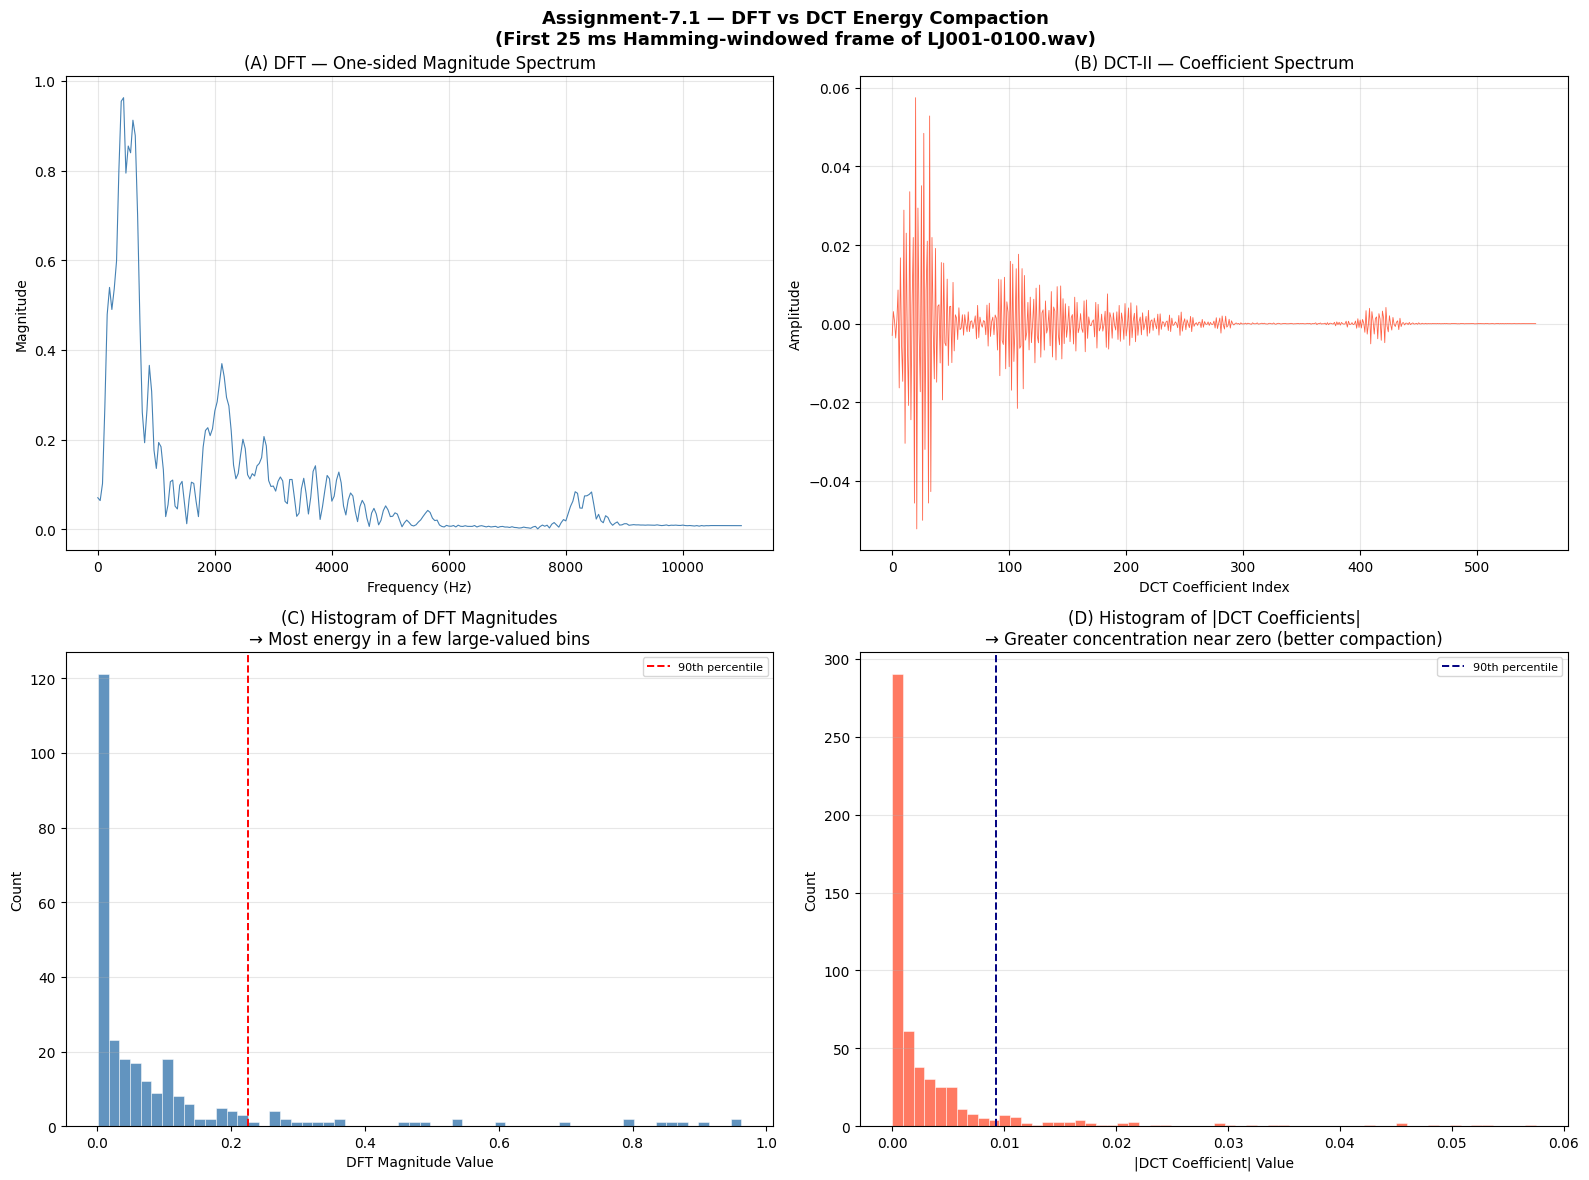

Saved: task1_dft_dct_histograms.png


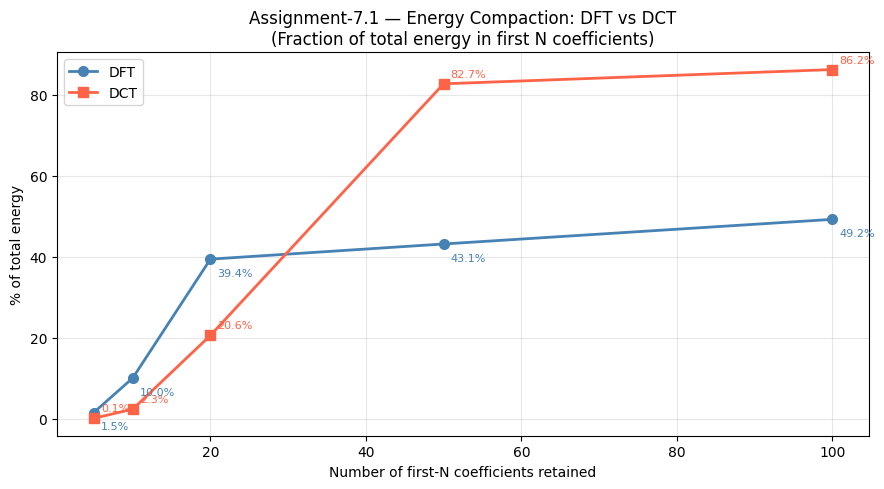

Saved: task1_energy_compaction_curve.png

--- Summary ---
Total DFT energy : 21.3715
Total DCT energy : 0.0388

With only the first 10 coefficients:
  DFT retains 10.02% of total energy
  DCT retains 2.32% of total energy

DCT compacts energy into fewer coefficients, making it more
efficient for speech representation and compression.

ASSIGNMENT-7.2  |  Task 2: MFCC Feature Extraction
MFCC matrix shape  : (13, 216)  (n_mfcc × n_frames)
Number of frames   : 216
Frame duration     : 92.9 ms
Hop duration       : 23.2 ms
Time axis range    : 0 – 4.992 s


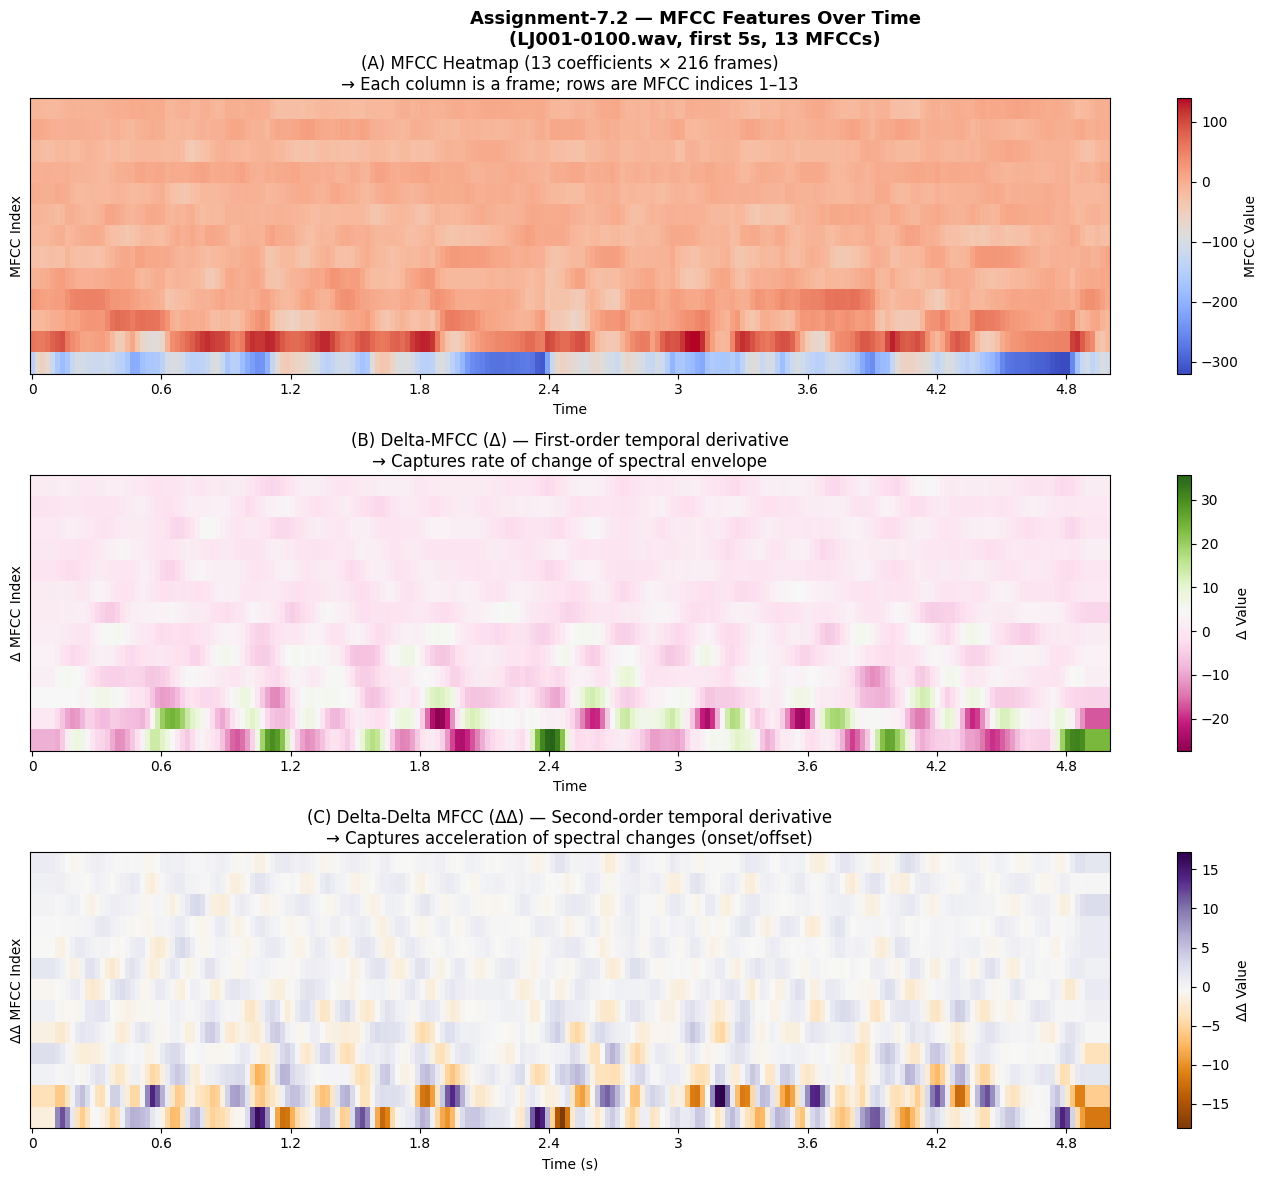

Saved: task2_mfcc_heatmap.png


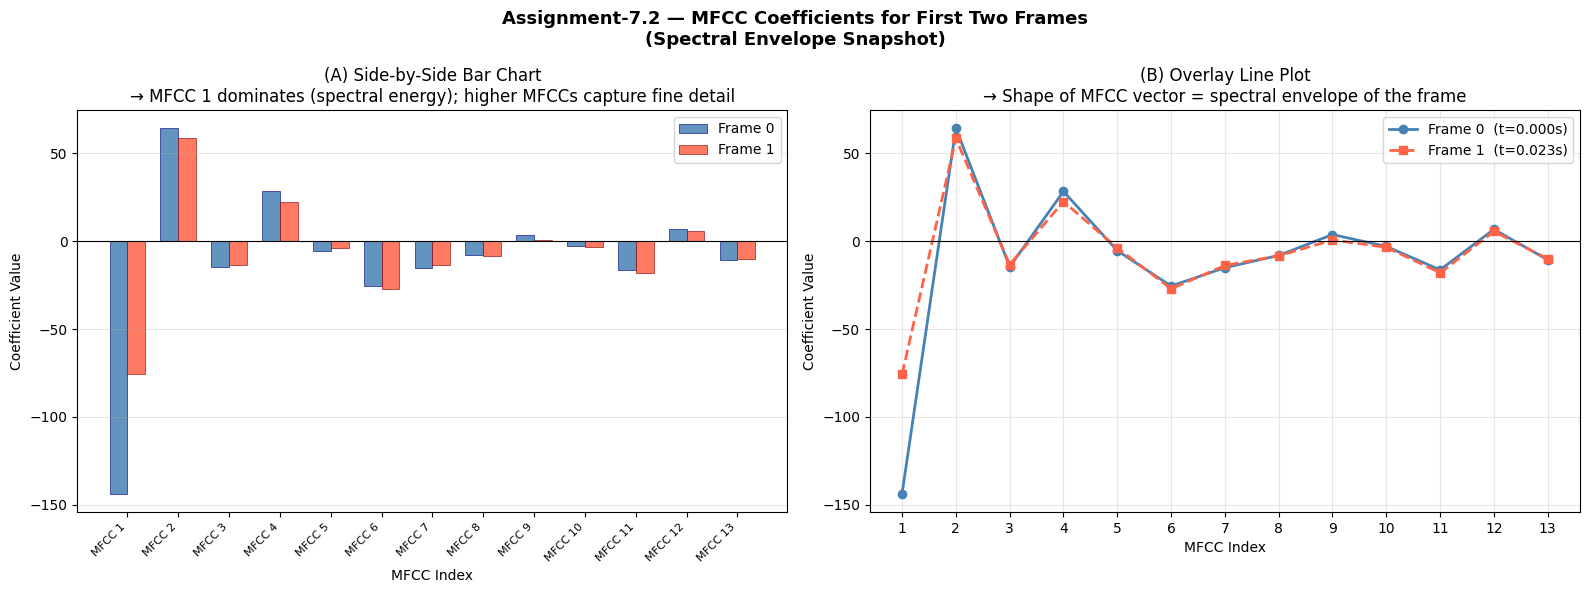

Saved: task2_mfcc_first_two_frames.png

--- MFCC Values: Frame 0 and Frame 1 ---
  MFCC |    Frame 0 |    Frame 1
--------------------------------
     1 |  -143.5614 |   -75.6951
     2 |    64.1413 |    58.3555
     3 |   -14.6581 |   -13.3621
     4 |    28.1885 |    22.4554
     5 |    -5.4696 |    -3.9204
     6 |   -25.5669 |   -27.1042
     7 |   -15.1328 |   -13.8592
     8 |    -8.1783 |    -8.3615
     9 |     3.6875 |     0.6086
    10 |    -3.0553 |    -3.5547
    11 |   -16.3592 |   -18.0314
    12 |     6.6662 |     5.4495
    13 |   -10.6896 |   -10.1180


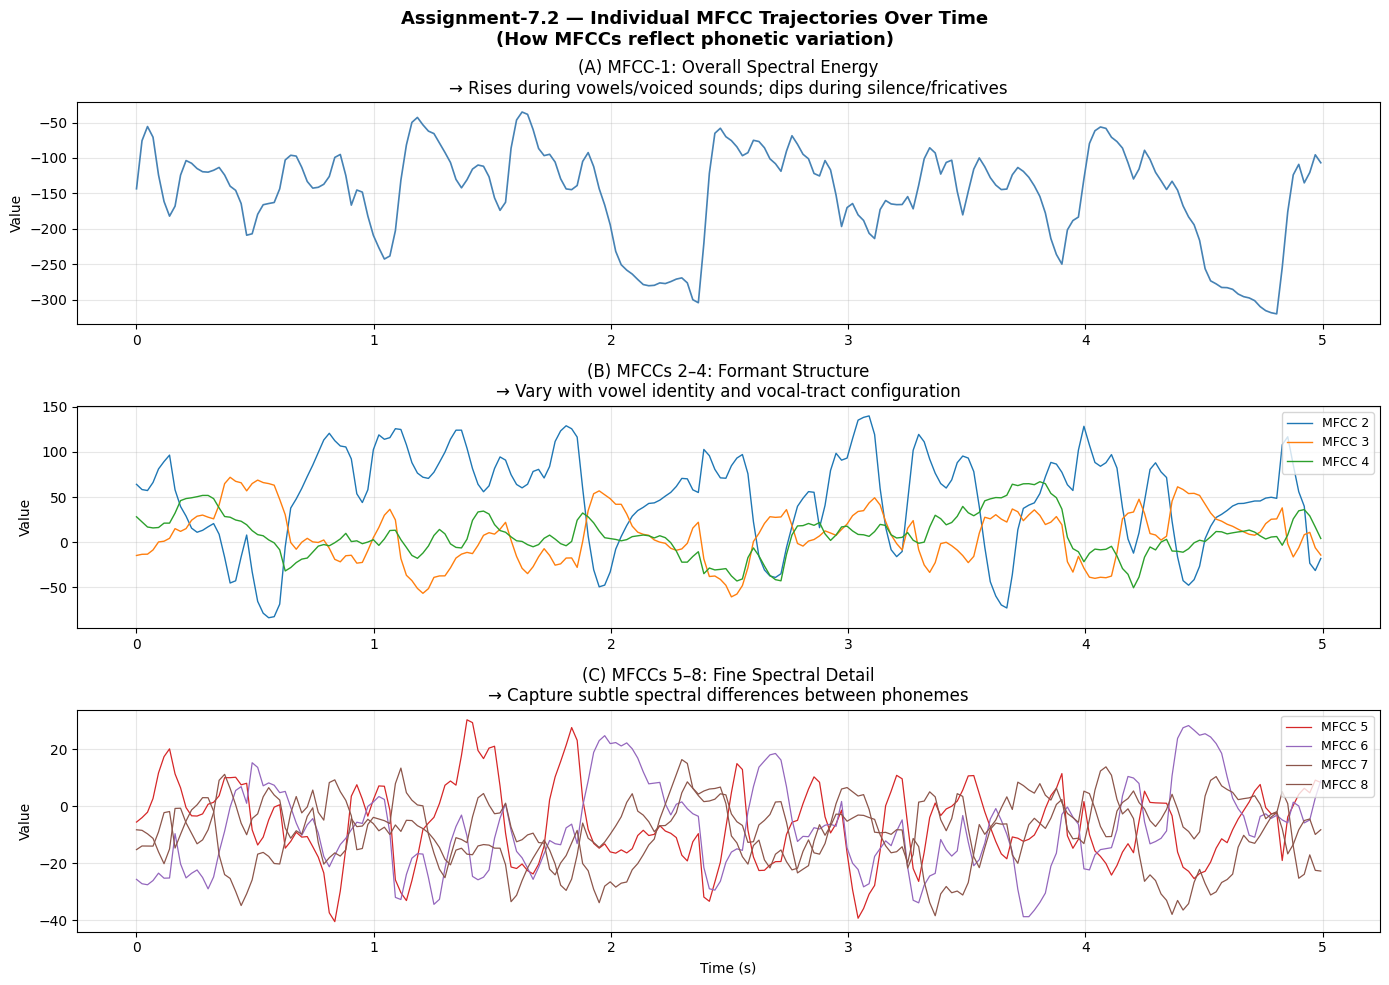

Saved: task2_mfcc_trajectories.png


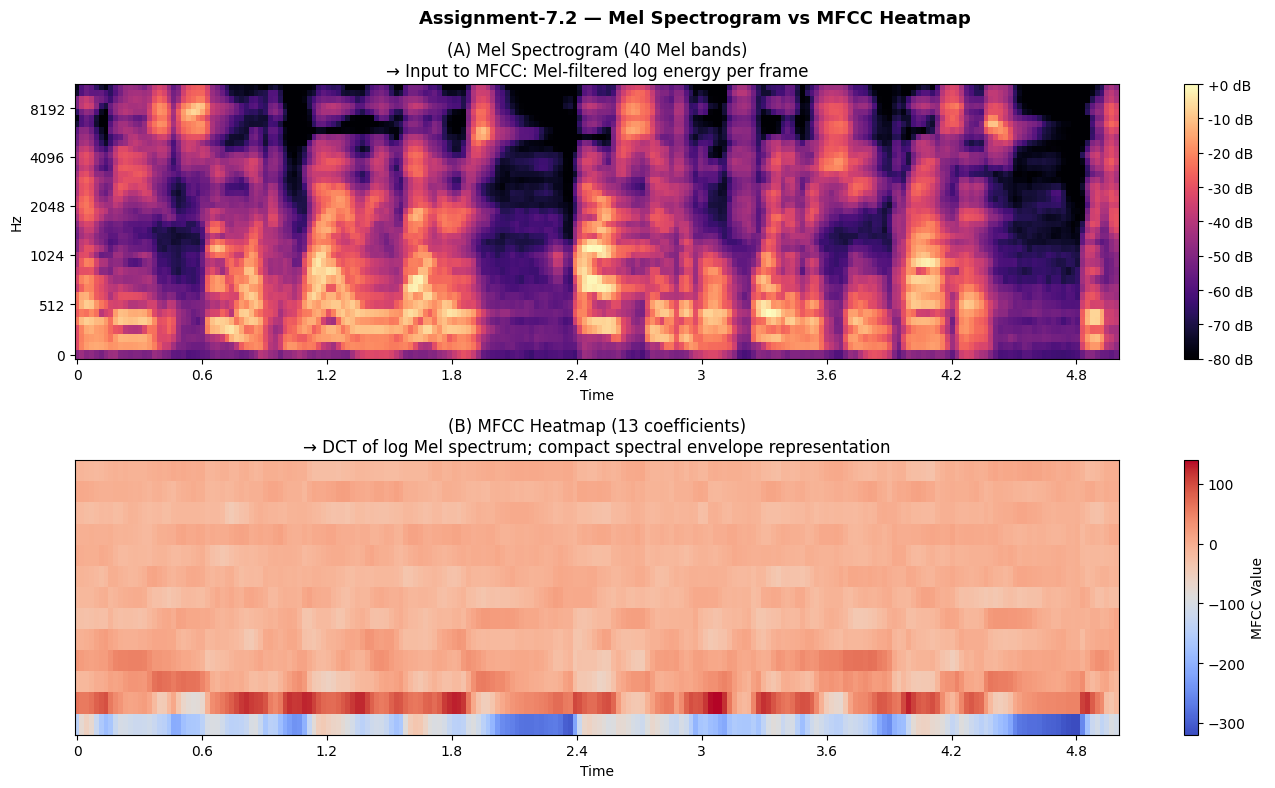

In [ ]:
# ============================================================
# LAB ASSIGNMENT 8
# ============================================================
# Assignment-7.1: DFT vs DCT Energy Compaction
#   Task-1:
#     i.   Load speech signal
#     ii.  Select first 25 ms frame + Hamming window
#     iii. Compute DFT and DCT
#     iv.  Compare energy compaction in first few coefficients
#     v.   Plot histogram for DFT and DCT
#
# Assignment-7.2: MFCC Feature Extraction
#   Task-2:
#     i.   Plot MFCC coefficients for each frame (over time)
#     ii.  Plot first few MFCCs for first two frames
#     iii. Explain phonetic variation
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa
import librosa.display
from scipy.fft import fft, dct

DATASET_DIR = "/kaggle/input/the-lj-speech-dataset/LJSpeech-1.1/wavs/"
FILE_PATH   = os.path.join(DATASET_DIR, "LJ001-0100.wav")

SR       = 22050    # LJ Speech native sample rate
DURATION = 5.0      # use first 5 seconds

y, sr = librosa.load(FILE_PATH, sr=SR, duration=DURATION)
print(f"File         : {os.path.basename(FILE_PATH)}")
print(f"Sample rate  : {sr} Hz")
print(f"Duration     : {len(y)/sr:.2f} s")

# Frame parameters
FRAME_MS  = 25                           # 25 ms
FRAME_LEN = int(sr * FRAME_MS / 1000)   # samples in one frame
print(f"Frame length : {FRAME_LEN} samples ({FRAME_MS} ms)")

# ASSIGNMENT-7.1 — DFT vs DCT ENERGY COMPACTION

# ---- Task-1 (i)  : Signal already loaded above ----
print("\n" + "="*60)
print("ASSIGNMENT-7.1  |  Task 1: DFT vs DCT Energy Compaction")
print("="*60)

# ---- Task-1 (ii) : First frame + Hamming window ----
first_frame = y[:FRAME_LEN]                       # first 25 ms
window      = np.hamming(FRAME_LEN)               # Hamming window
windowed    = first_frame * window

print(f"First frame  : samples 0 – {FRAME_LEN-1}  ({FRAME_LEN} samples)")
print(f"Window       : Hamming, length {FRAME_LEN}")

# ---- Task-1 (iii): Compute DFT and DCT ----
# DFT — full N-point magnitude for energy compaction, one-sided for spectrum plot
DFT_full = fft(windowed, n=FRAME_LEN)
DFT_mag  = np.abs(DFT_full[:FRAME_LEN // 2 + 1])  # one-sided magnitude (for spectrum plot)
DFT_mag_full = np.abs(DFT_full)                    # full N-point magnitude (for energy comparison)

# DCT-II (scipy uses ortho norm by default with norm='ortho')
DCT_coeff = dct(windowed, type=2, norm='ortho')   # real-valued, same length as input

print(f"\nDFT shape (one-sided, for plot)   : {DFT_mag.shape}")
print(f"DFT shape (full, for comparison) : {DFT_mag_full.shape}")
print(f"DCT shape                        : {DCT_coeff.shape}")

# ---- Task-1 (iv) : Energy compaction comparison ----
N_COEFF_LIST = [5, 10, 20, 50, 100]   # first-N coefficients to compare

# Total energies
total_energy_dft = np.sum(DFT_mag_full ** 2)
total_energy_dct = np.sum(DCT_coeff ** 2)

print("\n--- Energy Compaction: Fraction of total energy in first N coefficients ---")
print(f"{'N':>6} | {'DFT (%)':>10} | {'DCT (%)':>10}")
print("-" * 34)

compaction_dft = []
compaction_dct = []
for n in N_COEFF_LIST:
    frac_dft = np.sum(DFT_mag_full[:n] ** 2) / total_energy_dft * 100
    frac_dct = np.sum(DCT_coeff[:n] ** 2) / total_energy_dct * 100
    compaction_dft.append(frac_dft)
    compaction_dct.append(frac_dct)
    print(f"{n:>6} | {frac_dft:>10.2f} | {frac_dct:>10.2f}")

# ---- Task-1 (v) : Histogram plots ----
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "Assignment-7.1 — DFT vs DCT Energy Compaction\n"
    f"(First 25 ms Hamming-windowed frame of {os.path.basename(FILE_PATH)})",
    fontsize=13, fontweight='bold'
)

# --- Panel A: DFT magnitude spectrum ---
ax = axes[0, 0]
freqs = np.fft.rfftfreq(FRAME_LEN, d=1/sr)
ax.plot(freqs, DFT_mag, color='steelblue', linewidth=0.8)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude")
ax.set_title("(A) DFT — One-sided Magnitude Spectrum")
ax.grid(alpha=0.3)

# --- Panel B: DCT coefficients ---
ax = axes[0, 1]
coeff_idx = np.arange(len(DCT_coeff))
ax.plot(coeff_idx, DCT_coeff, color='tomato', linewidth=0.6)
ax.set_xlabel("DCT Coefficient Index")
ax.set_ylabel("Amplitude")
ax.set_title("(B) DCT-II — Coefficient Spectrum")
ax.grid(alpha=0.3)

# --- Panel C: Histogram of DFT magnitudes ---
ax = axes[1, 0]
ax.hist(DFT_mag, bins=60, color='steelblue', edgecolor='white',
        linewidth=0.4, alpha=0.85)
ax.set_xlabel("DFT Magnitude Value")
ax.set_ylabel("Count")
ax.set_title("(C) Histogram of DFT Magnitudes\n"
             "→ Most energy in a few large-valued bins")
ax.grid(alpha=0.3, axis='y')

# annotate fraction in first 10 bins
ax.axvline(np.percentile(DFT_mag, 90), color='red', linestyle='--',
           linewidth=1.4, label='90th percentile')
ax.legend(fontsize=8)

# --- Panel D: Histogram of DCT coefficients ---
ax = axes[1, 1]
ax.hist(np.abs(DCT_coeff), bins=60, color='tomato', edgecolor='white',
        linewidth=0.4, alpha=0.85)
ax.set_xlabel("|DCT Coefficient| Value")
ax.set_ylabel("Count")
ax.set_title("(D) Histogram of |DCT Coefficients|\n"
             "→ Greater concentration near zero (better compaction)")
ax.grid(alpha=0.3, axis='y')
ax.axvline(np.percentile(np.abs(DCT_coeff), 90), color='navy',
           linestyle='--', linewidth=1.4, label='90th percentile')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("task1_dft_dct_histograms.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: task1_dft_dct_histograms.png")

# --- Panel E: Energy compaction curve (both on one plot) ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(N_COEFF_LIST, compaction_dft, 'o-', color='steelblue',
        linewidth=2, markersize=7, label='DFT')
ax.plot(N_COEFF_LIST, compaction_dct, 's-', color='tomato',
        linewidth=2, markersize=7, label='DCT')
ax.set_xlabel("Number of first-N coefficients retained")
ax.set_ylabel("% of total energy")
ax.set_title("Assignment-7.1 — Energy Compaction: DFT vs DCT\n"
             "(Fraction of total energy in first N coefficients)")
ax.legend(); ax.grid(alpha=0.3)
for i, n in enumerate(N_COEFF_LIST):
    ax.annotate(f"{compaction_dct[i]:.1f}%",
                (n, compaction_dct[i]),
                textcoords="offset points", xytext=(5, 5),
                fontsize=8, color='tomato')
    ax.annotate(f"{compaction_dft[i]:.1f}%",
                (n, compaction_dft[i]),
                textcoords="offset points", xytext=(5, -12),
                fontsize=8, color='steelblue')
plt.tight_layout()
plt.savefig("task1_energy_compaction_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: task1_energy_compaction_curve.png")

# --- Summary table ---
print("\n--- Summary ---")
print(f"Total DFT energy : {total_energy_dft:.4f}")
print(f"Total DCT energy : {total_energy_dct:.4f}")
print(f"\nWith only the first 10 coefficients:")
print(f"  DFT retains {compaction_dft[1]:.2f}% of total energy")
print(f"  DCT retains {compaction_dct[1]:.2f}% of total energy")
print(f"\nDCT compacts energy into fewer coefficients, making it more")
print(f"efficient for speech representation and compression.")

# ASSIGNMENT-7.2 — MFCC FEATURE EXTRACTION
print("\n" + "="*60)
print("ASSIGNMENT-7.2  |  Task 2: MFCC Feature Extraction")
print("="*60)

# ---- MFCC parameters ----
N_MFCC   = 13      # number of MFCCs to extract
N_FFT    = 2048    # FFT window size
HOP_LEN  = 512     # hop length (≈ 23 ms at 22050 Hz)
N_MELS   = 40      # number of Mel filter banks

# ---- Compute MFCCs for the full 5-second signal ----
mfccs = librosa.feature.mfcc(
    y=y, sr=sr,
    n_mfcc=N_MFCC,
    n_fft=N_FFT,
    hop_length=HOP_LEN,
    n_mels=N_MELS,
    fmin=0,
    fmax=sr // 2
)   # shape: (n_mfcc, n_frames)

# Delta and delta-delta (for richer analysis)
mfcc_delta  = librosa.feature.delta(mfccs)
mfcc_delta2 = librosa.feature.delta(mfccs, order=2)

n_total_frames = mfccs.shape[1]
time_axis      = librosa.frames_to_time(
    np.arange(n_total_frames), sr=sr, hop_length=HOP_LEN)

print(f"MFCC matrix shape  : {mfccs.shape}  (n_mfcc × n_frames)")
print(f"Number of frames   : {n_total_frames}")
print(f"Frame duration     : {N_FFT/sr*1000:.1f} ms")
print(f"Hop duration       : {HOP_LEN/sr*1000:.1f} ms")
print(f"Time axis range    : 0 – {time_axis[-1]:.3f} s")

# ---- Task-2 (i) : Plot MFCCs for each frame (over time) ----
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle(
    "Assignment-7.2 — MFCC Features Over Time\n"
    f"({os.path.basename(FILE_PATH)}, first {DURATION:.0f}s, {N_MFCC} MFCCs)",
    fontsize=13, fontweight='bold'
)

# MFCC heatmap
ax = axes[0]
img = librosa.display.specshow(
    mfccs, x_axis='time', sr=sr, hop_length=HOP_LEN,
    ax=ax, cmap='coolwarm'
)
ax.set_ylabel("MFCC Index")
ax.set_title(f"(A) MFCC Heatmap ({N_MFCC} coefficients × {n_total_frames} frames)\n"
             "→ Each column is a frame; rows are MFCC indices 1–13")
plt.colorbar(img, ax=ax, label="MFCC Value")

# Delta-MFCC heatmap
ax = axes[1]
img2 = librosa.display.specshow(
    mfcc_delta, x_axis='time', sr=sr, hop_length=HOP_LEN,
    ax=ax, cmap='PiYG'
)
ax.set_ylabel("Δ MFCC Index")
ax.set_title("(B) Delta-MFCC (Δ) — First-order temporal derivative\n"
             "→ Captures rate of change of spectral envelope")
plt.colorbar(img2, ax=ax, label="Δ Value")

# Delta-delta MFCC heatmap
ax = axes[2]
img3 = librosa.display.specshow(
    mfcc_delta2, x_axis='time', sr=sr, hop_length=HOP_LEN,
    ax=ax, cmap='PuOr'
)
ax.set_ylabel("ΔΔ MFCC Index")
ax.set_xlabel("Time (s)")
ax.set_title("(C) Delta-Delta MFCC (ΔΔ) — Second-order temporal derivative\n"
             "→ Captures acceleration of spectral changes (onset/offset)")
plt.colorbar(img3, ax=ax, label="ΔΔ Value")

plt.tight_layout()
plt.savefig("task2_mfcc_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: task2_mfcc_heatmap.png")

# ---- Task-2 (ii) : First few MFCCs for the first two frames ----
frame_0 = mfccs[:, 0]   # Frame 0
frame_1 = mfccs[:, 1]   # Frame 1

mfcc_labels = [f"MFCC {i+1}" for i in range(N_MFCC)]
x = np.arange(N_MFCC)
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    "Assignment-7.2 — MFCC Coefficients for First Two Frames\n"
    "(Spectral Envelope Snapshot)",
    fontsize=13, fontweight='bold'
)

# Bar chart: side-by-side Frame 0 and Frame 1
ax = axes[0]
bars1 = ax.bar(x - width/2, frame_0, width, label='Frame 0',
               color='steelblue', alpha=0.85, edgecolor='navy', linewidth=0.5)
bars2 = ax.bar(x + width/2, frame_1, width, label='Frame 1',
               color='tomato',    alpha=0.85, edgecolor='darkred', linewidth=0.5)
ax.set_xlabel("MFCC Index"); ax.set_ylabel("Coefficient Value")
ax.set_title("(A) Side-by-Side Bar Chart\n"
             "→ MFCC 1 dominates (spectral energy); higher MFCCs capture fine detail")
ax.set_xticks(x); ax.set_xticklabels(mfcc_labels, rotation=45, ha='right', fontsize=8)
ax.axhline(0, color='black', linewidth=0.8)
ax.legend(); ax.grid(alpha=0.3, axis='y')

# Line plot overlay: both frames
ax = axes[1]
ax.plot(x, frame_0, 'o-', color='steelblue', linewidth=2,
        markersize=6, label=f'Frame 0  (t={time_axis[0]:.3f}s)')
ax.plot(x, frame_1, 's--', color='tomato', linewidth=2,
        markersize=6, label=f'Frame 1  (t={time_axis[1]:.3f}s)')
ax.set_xlabel("MFCC Index"); ax.set_ylabel("Coefficient Value")
ax.set_title("(B) Overlay Line Plot\n"
             "→ Shape of MFCC vector = spectral envelope of the frame")
ax.set_xticks(x); ax.set_xticklabels([str(i+1) for i in range(N_MFCC)])
ax.axhline(0, color='black', linewidth=0.8)
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("task2_mfcc_first_two_frames.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: task2_mfcc_first_two_frames.png")

# ---- Print numeric values ----
print("\n--- MFCC Values: Frame 0 and Frame 1 ---")
print(f"{'MFCC':>6} | {'Frame 0':>10} | {'Frame 1':>10}")
print("-" * 32)
for i in range(N_MFCC):
    print(f"  {i+1:>4} | {frame_0[i]:>10.4f} | {frame_1[i]:>10.4f}")

# ---- Task-2 (iii): MFCC time series for individual coefficients ----
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle(
    "Assignment-7.2 — Individual MFCC Trajectories Over Time\n"
    "(How MFCCs reflect phonetic variation)",
    fontsize=13, fontweight='bold'
)

colors = plt.cm.tab10(np.linspace(0, 1, N_MFCC))

# MFCC 1 (energy-like)
ax = axes[0]
ax.plot(time_axis, mfccs[0], color='steelblue', linewidth=1.2)
ax.set_ylabel("Value")
ax.set_title("(A) MFCC-1: Overall Spectral Energy\n"
             "→ Rises during vowels/voiced sounds; dips during silence/fricatives")
ax.grid(alpha=0.3)

# MFCCs 2-4 (formant-related)
ax = axes[1]
for i in range(1, 4):
    ax.plot(time_axis, mfccs[i], linewidth=1.0, color=colors[i],
            label=f'MFCC {i+1}')
ax.set_ylabel("Value")
ax.set_title("(B) MFCCs 2–4: Formant Structure\n"
             "→ Vary with vowel identity and vocal-tract configuration")
ax.legend(fontsize=9, loc='upper right'); ax.grid(alpha=0.3)

# MFCCs 5-8 (fine spectral detail)
ax = axes[2]
for i in range(4, 8):
    ax.plot(time_axis, mfccs[i], linewidth=0.9, color=colors[i],
            label=f'MFCC {i+1}')
ax.set_xlabel("Time (s)"); ax.set_ylabel("Value")
ax.set_title("(C) MFCCs 5–8: Fine Spectral Detail\n"
             "→ Capture subtle spectral differences between phonemes")
ax.legend(fontsize=9, loc='upper right'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("task2_mfcc_trajectories.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: task2_mfcc_trajectories.png")

# ---- Additional: Mel spectrogram for reference ----
mel_spec = librosa.feature.melspectrogram(
    y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LEN, n_mels=N_MELS)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("Assignment-7.2 — Mel Spectrogram vs MFCC Heatmap",
             fontsize=13, fontweight='bold')

ax = axes[0]
img = librosa.display.specshow(
    mel_spec_db, x_axis='time', y_axis='mel',
    sr=sr, hop_length=HOP_LEN, ax=ax, cmap='magma'
)
ax.set_title(f"(A) Mel Spectrogram ({N_MELS} Mel bands)\n"
             "→ Input to MFCC: Mel-filtered log energy per frame")
plt.colorbar(img, ax=ax, format='%+2.0f dB')

ax = axes[1]
img2 = librosa.display.specshow(
    mfccs, x_axis='time', sr=sr, hop_length=HOP_LEN,
    ax=ax, cmap='coolwarm'
)
ax.set_title(f"(B) MFCC Heatmap ({N_MFCC} coefficients)\n"
             "→ DCT of log Mel spectrum; compact spectral envelope representation")
plt.colorbar(img2, ax=ax, label="MFCC Value")

plt.tight_layout()
plt.savefig("task2_mel_vs_mfcc.png", dpi=150, bbox_inches='tight')
plt.show()